# Network Intrusion Detection — Binary Classifier

**Dataset:** NSL-KDD (benchmark for intrusion detection systems)  
**Task:** Binary classification — `normal` traffic vs. `attack` traffic  
**Model:** Multi-Layer Perceptron (MLP) neural network via scikit-learn

## 1. Imports

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

sns.set_theme(style='whitegrid')
os.makedirs('outputs', exist_ok=True)
print('All imports OK')

All imports OK


## 2. Load the NSL-KDD Dataset

In [2]:
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty',
]
CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']
FEATURE_COLS = [c for c in COLUMNS if c not in ('label', 'difficulty')]

BASE_URL = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/'
FILES = {
    'KDDTrain+.txt': 'data/train.txt',
    'KDDTest+.txt':  'data/test.txt',
}

os.makedirs('data', exist_ok=True)
for remote, local in FILES.items():
    if not os.path.exists(local):
        print(f'Downloading {remote} …')
        urllib.request.urlretrieve(BASE_URL + remote, local)
    else:
        print(f'{local} already present')

train_df = pd.read_csv('data/train.txt', names=COLUMNS)
test_df  = pd.read_csv('data/test.txt',  names=COLUMNS)

print(f'\nTrain: {train_df.shape}   Test: {test_df.shape}')
train_df.head()

data/train.txt already present
data/test.txt already present



Train: (125973, 43)   Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Exploratory Data Analysis

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [4]:
# Binary label: 0 = normal, 1 = attack
for df in (train_df, test_df):
    df['binary_label'] = (df['label'] != 'normal').astype(int)

print('=== Train label distribution ===')
print(train_df['label'].value_counts())
print('\n=== Test label distribution ===')
print(test_df['label'].value_counts())

=== Train label distribution ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

=== Test label distribution ===
label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetat

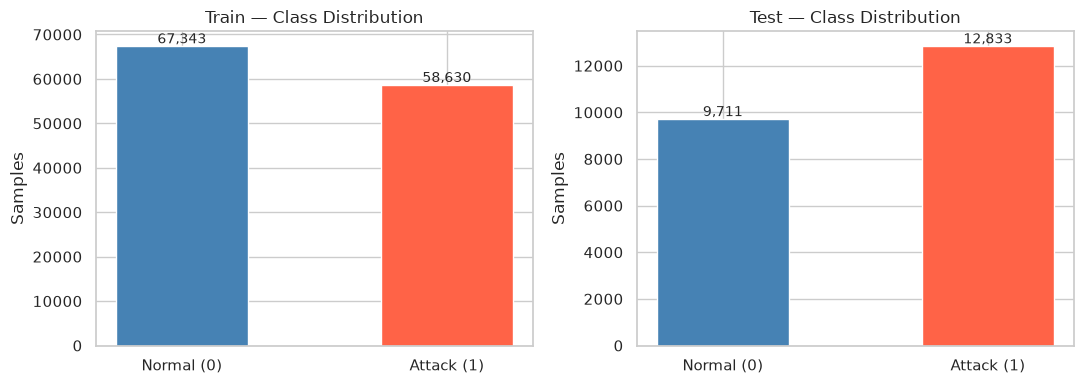

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    counts = df['binary_label'].value_counts().sort_index()
    ax.bar(['Normal (0)', 'Attack (1)'], counts.values, color=['steelblue', 'tomato'], width=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.01, f'{v:,}', ha='center', fontsize=10)
    ax.set_title(f'{title} — Class Distribution')
    ax.set_ylabel('Samples')
plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=150)
plt.show()

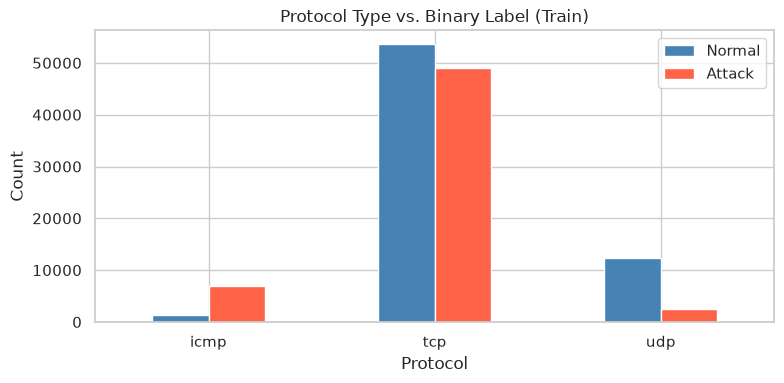

In [6]:
# Protocol type vs label
fig, ax = plt.subplots(figsize=(8, 4))
cross = pd.crosstab(train_df['protocol_type'], train_df['binary_label'])
cross.columns = ['Normal', 'Attack']
cross.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Protocol Type vs. Binary Label (Train)')
ax.set_xlabel('Protocol')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('outputs/protocol_distribution.png', dpi=150)
plt.show()

## 4. Preprocessing

In [7]:
# Step 1 — Select raw features
X_train_raw = train_df[FEATURE_COLS].copy()
X_test_raw  = test_df[FEATURE_COLS].copy()
print(f'After feature selection  — train: {X_train_raw.shape}  test: {X_test_raw.shape}')

# Step 2 — One-hot encode categorical columns
X_train_raw = pd.get_dummies(X_train_raw, columns=CATEGORICAL_COLS, dtype=float)
X_test_raw  = pd.get_dummies(X_test_raw,  columns=CATEGORICAL_COLS, dtype=float)
print(f'After one-hot encoding   — train: {X_train_raw.shape}  test: {X_test_raw.shape}')

# Step 3 — Align columns (test may lack categories unseen during training)
X_train_raw, X_test_raw = X_train_raw.align(X_test_raw, join='left', axis=1, fill_value=0)
print(f'After column alignment   — train: {X_train_raw.shape}  test: {X_test_raw.shape}')

# Step 4 — Binary labels
y_train = train_df['binary_label'].values
y_test  = test_df['binary_label'].values
print(f'Labels — train: {y_train.shape}  test: {y_test.shape}')

# Step 5 — Normalize with StandardScaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
print(f'After StandardScaler     — train: {X_train.shape}  test: {X_test.shape}')

After feature selection  — train: (125973, 41)  test: (22544, 41)
After one-hot encoding   — train: (125973, 122)  test: (22544, 116)
After column alignment   — train: (125973, 122)  test: (22544, 122)
Labels — train: (125973,)  test: (22544,)


After StandardScaler     — train: (125973, 122)  test: (22544, 122)


## 5. Model — Multi-Layer Perceptron

Architecture: **input → 128 → 64 → 32 → output (sigmoid)**  
Optimizer: Adam | Activation: ReLU | Early stopping on validation loss

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False,
)

print('Training …')
mlp.fit(X_train, y_train)
print(f'Done — stopped at epoch {mlp.n_iter_}')

Training …


Done — stopped at epoch 43


## 6. Evaluation

In [9]:
y_pred      = mlp.predict(X_test)
y_prob      = mlp.predict_proba(X_test)[:, 1]

accuracy    = accuracy_score(y_test, y_pred)
report      = classification_report(y_test, y_pred, target_names=['Normal', 'Attack'])

print(f'Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print()
print(report)

with open('outputs/classification_report.txt', 'w') as f:
    f.write(f'Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)\n\n')
    f.write(report)

Test Accuracy : 0.8097 (80.97%)

              precision    recall  f1-score   support

      Normal       0.70      0.97      0.81      9711
      Attack       0.97      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



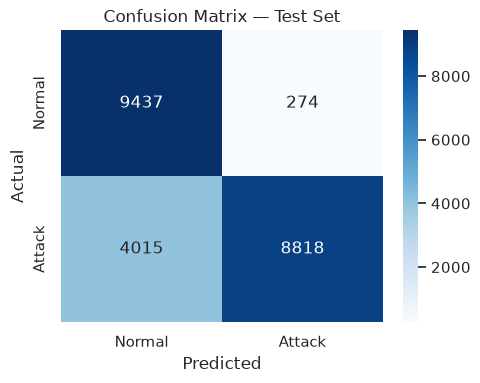

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

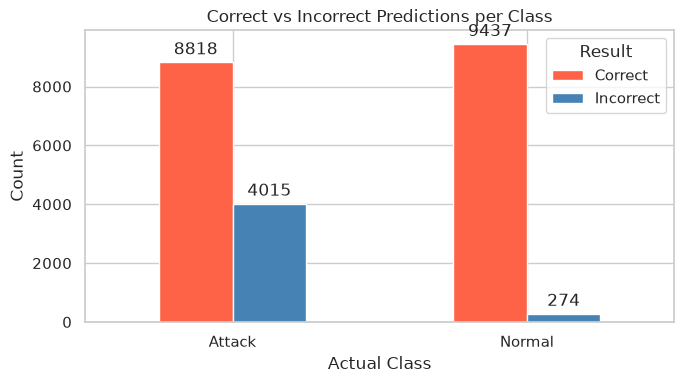

In [11]:
# Correct vs Incorrect predictions per class
results = pd.DataFrame({
    'Actual': ['Normal' if l == 0 else 'Attack' for l in y_test],
    'Result': ['Correct' if c else 'Incorrect' for c in (y_pred == y_test)],
})
counts = results.groupby(['Actual', 'Result']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind='bar', ax=ax, color=['tomato', 'steelblue'])
ax.set_title('Correct vs Incorrect Predictions per Class')
ax.set_xlabel('Actual Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.savefig('outputs/correct_vs_incorrect.png', dpi=150)
plt.show()

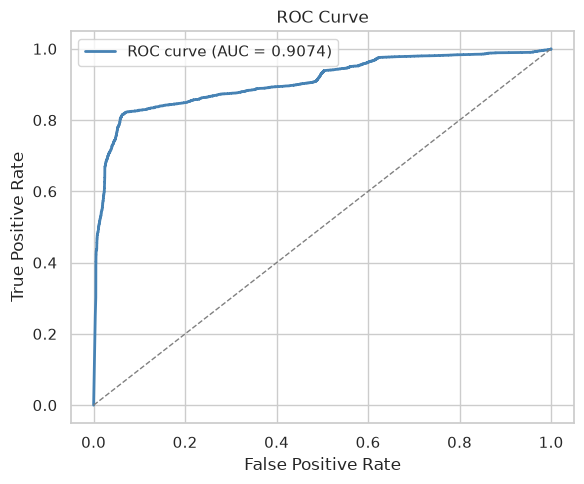

In [12]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150)
plt.show()

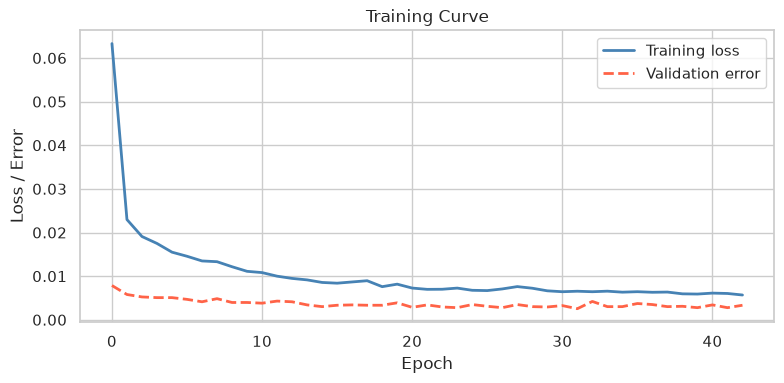

In [13]:
# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='steelblue', lw=2, label='Training loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    val_error = [1 - s for s in mlp.validation_scores_]
    plt.plot(val_error, color='tomato', lw=2, linestyle='--', label='Validation error')
plt.xlabel('Epoch')
plt.ylabel('Loss / Error')
plt.title('Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/training_curve.png', dpi=150)
plt.show()

## 7. Summary

| Metric | Value |
|--------|-------|
| Accuracy | see above |
| AUC-ROC | see above |
| Architecture | 128 → 64 → 32 (ReLU, Adam) |
| Dataset | NSL-KDD (KDDTrain+ / KDDTest+) |

**Key takeaways:**
- NSL-KDD is a cleaner version of KDD Cup 99 (removes duplicate records that bias accuracy).
- One-hot encoding handles the categorical features (protocol, service, flag).
- StandardScaler is essential — raw byte counts span many orders of magnitude.
- The MLP achieves high accuracy because many attack types have very distinct byte/packet patterns.